# SIR simulation in a grid

Simulate parameters from a specific range. Plot the pairs of simulated parameters in a grid. Plot also the "density" representing the distance measure (likelihood approximation from [Lintusaari et al 2016](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ )).


Ranges for $\beta$, $\gamma$ (from Lintusaari et al 2016)
- $\beta = [0.3, 2]$
- $\gamma = [0.0125, 1.5]$
 - NOTE: these are not the birth and death rates as in a birth-death process. These are the transmission coefficient and the recovery rate of an SIR model. The ranges from Lintusaari et al 2016 are probably not directly applicable here.
 

Approximate likelihood function:

$$\hat{L}(\theta) \propto \frac{1}{N}\sum_{i = 1}^N1_{[0,\epsilon]}[d(a^*, a)]$$


Design choices: distance function, threshold, summaries, range of $\beta$ and $\gamma$

**TODO**
 - Simulation parameters DONE
 - Add likelihood function to notebook
 - Approx. likelihood function
 - Choose between simulated observed data and actual observed data TODO

**Questions**
- Should the grid be evenly spaced? Should I only simulate at these evenly spaced points?
- Is this a type of maximum likelihood estimation?
- How to choose epsilon?


**Sources**
- On the identifiability of transmission dynamic models for infectious disease: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ 




In [34]:
import numpy as np
import matplotlib.pyplot as plt
from cluster.scripts.load_data import * # import data: odds ratios, BSI...

In [117]:
# Step 1: Approximation of the likelihood function


def approx_likelihood(dist, epsilon=0.0001):
    # Calculates the approximate likelihood over N simulations for a given parameter pair
    # dist: distances between the simulated and observed sequences over N simulations
    
    N = dist.shape[0]
    lik = 0
    for d in dist:
        #print(d)
        
        if d < epsilon:
            lik += d
    
    return 1/N*lik

    
# Distance function

# TODO: add summaries here 
def BSI_max_t(y):
    # time to peak/maximum number of bsi cases
    
    return np.argmax(y)

def BSI_max(y):
    # maximum number of BSI cases
    
    max_bsi = np.max(y)
    
    return max_bsi#.reshape(-1,1).transpose()

def distance(sim, obs, S1_fun, S2_fun):
    # Euclidean distance between the simulated and observed sequence
    # d(a*, a) where a* is the observed sequence and a is the simulated sequence
    # sim: simulated sequence
    # obs: observed sequence
    # S1_fun, S2_fun: summary functions that return a scalar summary based on the input sequence
    
    S1_obs = S1_fun(obs)
    S2_obs = S2_fun(obs)
    
    S1_sim = S1_fun(sim)
    S2_sim = S2_fun(sim)
    
    
    return np.sqrt((S1_sim - S1_obs)**2 + (S2_sim - S2_obs)**2)
    

In [118]:
# Step 2: Simulation function, observed data (import from file)

import importlib
import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) 

from cluster.scripts.BSI_functions import *

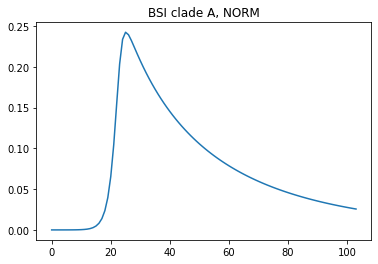

In [119]:
# Observed data:

# First, synthetic data:

pop_size = 100000
n_weeks = 104
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.735]), np.array([0.0223]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

In [148]:
# Step 3: Running the simulation over pairs of parameters and get the approximate likelihood

# Pick parameters for the simulation

# dimensions of the grid to simulate
n_beta = 50
n_gamma = 40

N_sim = 100 # number of simulations at each point in the grid
e = 0.01 # epsilon, large enough epsilon means that all distances will be in the grid

beta_range = (0.5, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

def approx_likelihood_grid(beta_range, gamma_range, n_beta, n_gamma, N_sim, e, bsi_obs):
    betas = np.linspace(beta_range[0], beta_range[1], n_beta)
    gammas = np.linspace(gamma_range[0], gamma_range[1], n_gamma)

    approx_lik_mat= np.zeros((n_beta, n_gamma))
    iters = 0
    for i in range(0, n_beta):
        for j in range(0, n_gamma):

            if iters%100 == 0:
                print("Iter:", iters)
            beta = betas[i]
            gamma = gammas[j]

            distances = np.zeros(N_sim)

            for h in range(0, N_sim):
                sim_seq = SIR_and_BSI_simulator(beta, gamma, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = False, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]
                distances[h] = distance(sim_seq, bsi_obs, BSI_max, BSI_max_t)

            # Calculate the approximate likelihood for this parameter pair:

            L_hat = approx_likelihood(distances, epsilon=e)
            if not isinstance(L_hat, float):
                print(f"Warning! Not float. Iter {iters}.")
                print(L_hat)
                print(f"Parameter pair: {beta}, {gamma}")
            else:
                approx_lik_mat[i,j] = L_hat

            iters += 1
    
    return approx_lik_mat, betas, gammas

approx_lik_mat, betas, gammas = approx_likelihood_grid(beta_range, gamma_range, n_beta, n_gamma, N_sim, e, bsi_obs[0])

Iter: 0


KeyboardInterrupt: 

In [135]:
# Step 5: Visualize the approximate likelihood over the grid of parameters

print(approx_lik_mat.shape) # (n_betas, n_gammas)

(50, 40)


In [137]:
def hide_ticks(ax_get_tick_labels, nth):
    # Based on: https://stackoverflow.com/questions/6682784/reducing-number-of-plot-ticks
    # ax_get_tick_labels: ax.xaxis.get_ticklabels() or ax.yaxis.get_ticklabels()
    # nth: which labels are shown?
    
    for n, label in enumerate(ax_get_tick_labels):
        if n % nth != 0:
            label.set_visible(False)
    

In [187]:
def plot_heatmap(mat, betas, gammas, title, cbar_label, nth = 4):
    # mat: matrix of interest, approximate likelihoods or distances for example
    # betas: row labels (parameter values at the row)
    # gammas: col labels (parameter values)
    # title: title of the plot
    # cbar_label: color bar label
    # nth: how "manyeth" tick label is displayed
    
    fig, ax = plt.subplots(figsize=(10, 10))

    row_labels = np.round(betas, 2)
    col_labels = np.round(gammas,2)

    im = ax.imshow(mat)
    ax.set_yticks(np.arange(mat.shape[0]), labels=row_labels)
    ax.set_xticks(np.arange(mat.shape[1]), labels=col_labels, rotation = 45)
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Beta")
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbar_label, rotation=-90, va="bottom")
    ax.set_title(title)

    hide_ticks(ax.xaxis.get_ticklabels(), nth = nth)
    hide_ticks(ax.yaxis.get_ticklabels(), nth = nth)

    plt.show()

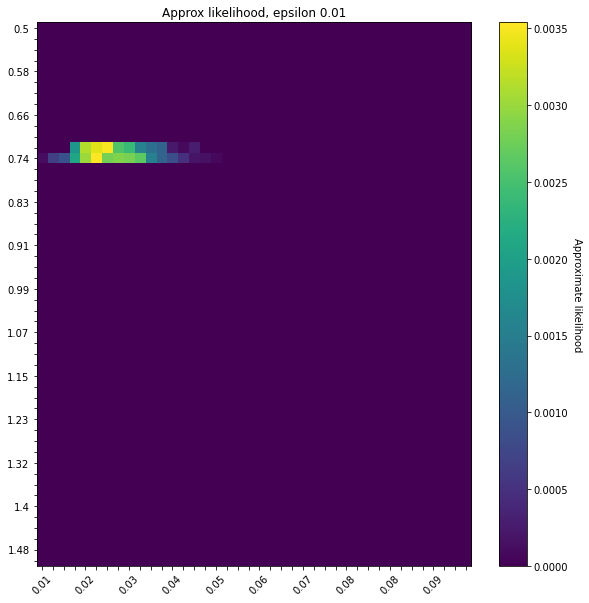

In [145]:
plot_heatmap(approx_lik_mat, betas, gammas, f"Approx likelihood, epsilon {e}", "Approximate likelihood")

Gammatx-akselilla, betat y-akselilla tässä.

## Distance between observed and simulated sequence summaries at $\beta, \gamma$

Do not calculate the likelihood but rather the distance between observed and simulated summaries at a given data pair directly

In [199]:
# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.5, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate


def get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, bsi_obs, is_agg = False):
    # Get the distance between pairs of gamma and beta in the given range
    
    betas = np.linspace(beta_range[0], beta_range[1], n_beta)
    gammas = np.linspace(gamma_range[0], gamma_range[1], n_gamma)

    dist_mat = np.zeros((n_beta, n_gamma))
    iters = 0

    for i in range(0, n_beta):
        for j in range(0, n_gamma):

            if iters%200 == 0:
                print("Iter:", iters)
            beta = betas[i]
            gamma = gammas[j]

            sim_seq = SIR_and_BSI_simulator(beta, gamma, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = is_agg, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]

            dist = distance(sim_seq, bsi_obs[0], BSI_max, BSI_max_t)

            if not isinstance(dist, float):
                print(f"Warning! Not float. Iter {iters}.")
                print(dist)
                print(f"Parameter pair: {beta}, {gamma}")
            else:
                dist_mat[i,j] = dist

            iters += 1
            
    return dist_mat, betas, gammas # return betas and gammas for plotting purposes

In [200]:
dist_mat, betas, gammas = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, bsi_obs)

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800


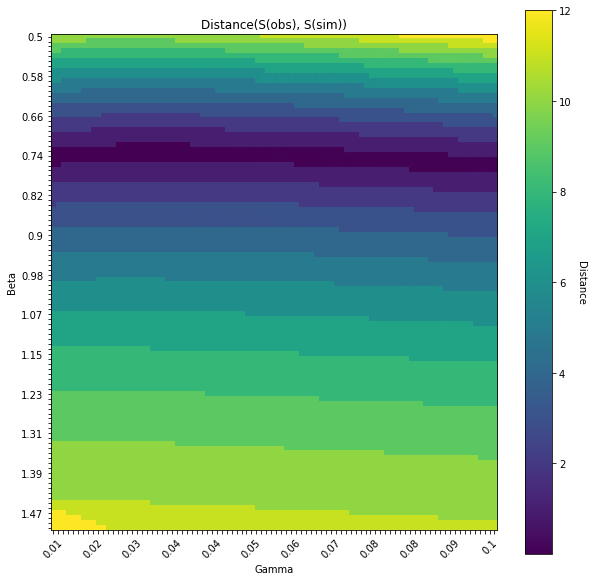

In [201]:
plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8)

### Potential issues

- Different scales on the y and x axis might impact the distance calculation - is the same treshold applicaple to both parameters? Should some standardization/normalization happen here?

# Distance matrix between real observed data and simulations

Previously, synthetic data was used as the "observed" data. This time, we compare real and simulated data.

Note that real data has less data points than observed data and these data points are yearly observations instead of weekly ones. We need aggregate the simulated data to match the yearly observed data. Or alternatively, augment the observed data to be weekly. Or simply use the summaries, and not force the simulated and observed sequences to be the same length (here, the different time scales need to be taken into account though).


In [202]:
# Get the observed data

from cluster.scripts.load_data import *
obs_data = "NORM"

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


In [203]:
print(BSI_max_t(bsi_obs_data)) # year 2013, 11 years from beginning (2002)
print(BSI_max(bsi_obs_data)) # max proportion of cases
print(len(bsi_obs_data))

11
0.047058823529411764
16


[5.57466798e-05 1.14164603e-05 2.33658498e-06 4.78165223e-07
 9.78505791e-08 2.00238030e-08 4.09759724e-09 8.38517014e-10
 1.71590986e-10 3.51137374e-11 7.18554382e-12 1.47042280e-12
 3.00901820e-13 6.15754224e-14 1.26005640e-14 2.57853227e-15]
16
0
5.57466797894317e-05


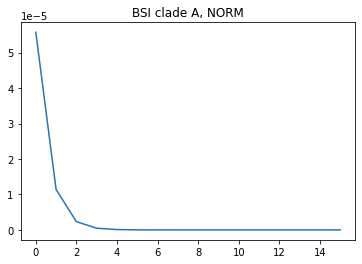

In [204]:
# aggregate simulated data:
n_weeks = 16*52
test_bsi_obs = SIR_and_BSI_simulator(0.37, 0.4, nt = n_weeks, N = pop_size, bsi_pars = bsi_pars,\
                                is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                batch_size = 1, random_state = None)[0]
print(test_bsi_obs)
print(len(test_bsi_obs))

print(BSI_max_t(test_bsi_obs))
print(BSI_max(test_bsi_obs))

# Plot the aggregated synthetic observed data:
plt.plot(test_bsi_obs)
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

In [195]:
# Problem: same beta and gamma produce vastly differing BSI curves. True or false?
# - If true, then the odds ratio uncertainty has a high impact on the BSI, perhaps too much so.
# - If false, all good.



In [205]:
# Grid simulation
# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.01, 1.5) # range of beta values to simulate; has to be large enough to find the small distance areas,
# which can then be used to refine this range further. And used as values for synthetic data.
gamma_range = (0.0125, 1) # range of gamma values to simulate

dist_mat, betas, gammas = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, bsi_obs_data, is_agg = True)

Iter: 0


KeyError: 0

In [ ]:
# Visualisation

plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8)

### Notes
- Increasing the range of gamma here: distance is smallest when the parameters are the same. Does this make sense? I think yes, in the euclidean space.
- However, when simulating with for example $\beta = 0.37$ and $\gamma = 0.40$ the resulting figure is nowhere near the real data and its peaks.
    - TODO: with repetitions.
- **Q**: What if $\beta$ (transmission coefficient) and $\gamma$ (recovery rate) have different scales, as prior knowledge would suggest (time to clearance of colonization from a previous study?
- **Q**: Can $\beta$ and $\gamma$ have some correlation? I think not, since transmission and recovery intuitively seem like separate events.
- **Q**: Can different pairs of beta and gamma produce the same SIR figure?
- **Q**: Is euclidean distance the optimal distance metric here? I just chose it because it is easy.
- **Q**: Is there too much uncertainty related to the odds ratio data?

**Different combos to test:**
- Different odds ratios
- Different time periods of interest
- Create a new summary k (how "fast" the proportion of BSI cases increases)
- Priors
- Distance metrix, summaries, summary combos...

**Literature review of the following topics:**
- Distance metrics in general and in infectious disease, focus on their properties and where they are applied
- Infectious disease modeling: more theoretical background on the relationship between beta and gamma.

## Materials for visualisation
- "Smoothing" the heatmap: https://matplotlib.org/stable/gallery/images_contours_and_fields/interpolation_methods.html
